In [1]:
#project title 
#TELECOM CUSTOMER DATA ANALYSIS 

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
telecom=pd.read_csv("telecom_churns.csv")
telecom

,customer_id,age,gender,city,plan_type,monthly_bill,data_usage_gb,call_minutes,sms_count,complaints,customer_tenure_months,payment_method,network_quality,support_calls,device_type,churn_status,customer_rating
0,C10047,26.0,Male,Pune,Basic,2295.08,28.34,174,54,3,18,UPI,Poor,6,Android,Yes,1.7
1,C10291,46.0,Male,Trichy,Standard,1021.97,9.16,441,53,2,51,Debit Card,Poor,1,Android,Yes,2.9
2,C10755,31.0,Male,Mumbai,Premium,1196.50,29.23,360,48,1,54,UPI,Average,2,iPhone,No,3.0
3,C10449,22.0,Male,Madurai,Standard,2389.49,34.39,292,52,1,16,UPI,Average,2,Android,Yes,2.9
4,C10912,21.0,Female,Coimbatore,Standard,1168.94,6.19,478,56,2,83,Net Banking,Excellent,3,Android,No,2.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1207,C11145,53.0,Male,Chennai,Basic,926.85,20.36,393,45,3,57,Credit Card,Excellent,0,Feature Phone,No,3.4
1208,C10369,19.0,Male,Bengaluru,Basic,1497.56,9.35,24,41,3,17,UPI,Good,0,Android,No,3.5
1209,C10049,19.0,Male,NaN,Standard,925.28,35.92,157,53,2,81,Auto Pay,Good,2,Android,No,3.3
1210,C10773,29.0,Female,Bengaluru,Premium,NaN,34.08,525,55,1,31,NaN,Excellent,1,iPhone,Yes,2.5


In [4]:
telecom.head()

,customer_id,age,gender,city,plan_type,monthly_bill,data_usage_gb,call_minutes,sms_count,complaints,customer_tenure_months,payment_method,network_quality,support_calls,device_type,churn_status,customer_rating
0,C10047,26.0,Male,Pune,Basic,2295.08,28.34,174,54,3,18,UPI,Poor,6,Android,Yes,1.7
1,C10291,46.0,Male,Trichy,Standard,1021.97,9.16,441,53,2,51,Debit Card,Poor,1,Android,Yes,2.9
2,C10755,31.0,Male,Mumbai,Premium,1196.50,29.23,360,48,1,54,UPI,Average,2,iPhone,No,3.0
3,C10449,22.0,Male,Madurai,Standard,2389.49,34.39,292,52,1,16,UPI,Average,2,Android,Yes,2.9
4,C10912,21.0,Female,Coimbatore,Standard,1168.94,6.19,478,56,2,83,Net Banking,Excellent,3,Android,No,2.6


In [5]:
telecom.tail()

,customer_id,age,gender,city,plan_type,monthly_bill,data_usage_gb,call_minutes,sms_count,complaints,customer_tenure_months,payment_method,network_quality,support_calls,device_type,churn_status,customer_rating
1207,C11145,53.0,Male,Chennai,Basic,926.85,20.36,393,45,3,57,Credit Card,Excellent,0,Feature Phone,No,3.4
1208,C10369,19.0,Male,Bengaluru,Basic,1497.56,9.35,24,41,3,17,UPI,Good,0,Android,No,3.5
1209,C10049,19.0,Male,NaN,Standard,925.28,35.92,157,53,2,81,Auto Pay,Good,2,Android,No,3.3
1210,C10773,29.0,Female,Bengaluru,Premium,NaN,34.08,525,55,1,31,NaN,Excellent,1,iPhone,Yes,2.5
1211,C10970,43.0,Male,Bengaluru,Unlimited,622.30,18.66,250,42,3,2,Net Banking,Average,0,iPhone,No,2.5


In [6]:
telecom.info() # Shows column names, data types, and non-null values 
telecom.describe()  #statistical summary of numerical columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             1212 non-null   object 
 1   age                     1188 non-null   float64
 2   gender                  1212 non-null   object 
 3   city                    1194 non-null   object 
 4   plan_type               1212 non-null   object 
 5   monthly_bill            1182 non-null   float64
 6   data_usage_gb           1188 non-null   float64
 7   call_minutes            1212 non-null   int64  
 8   sms_count               1212 non-null   int64  
 9   complaints              1212 non-null   int64  
 10  customer_tenure_months  1212 non-null   int64  
 11  payment_method          1194 non-null   object 
 12  network_quality         1188 non-null   object 
 13  support_calls           1212 non-null   int64  
 14  device_type             1212 non-null   

,age,monthly_bill,data_usage_gb,call_minutes,sms_count,complaints,customer_tenure_months,support_calls,customer_rating
count,1188.000000,1182.000000,1188.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000
mean,41.085017,1334.223113,17.302753,333.074257,44.853960,1.507426,47.789604,1.786304,3.406683
std,13.533895,660.237666,9.796131,194.445841,6.900206,1.243624,27.586772,1.290777,0.755118
min,18.000000,199.520000,1.370000,9.000000,22.000000,0.000000,1.000000,0.000000,1.000000
25%,29.000000,765.030000,9.927500,189.750000,40.000000,1.000000,23.000000,1.000000,2.900000
50%,42.000000,1313.570000,15.575000,295.000000,45.000000,1.000000,49.000000,2.000000,3.400000
75%,52.250000,1904.705000,22.892500,437.250000,49.000000,2.000000,72.000000,3.000000,4.000000
max,64.000000,2496.220000,63.800000,1223.000000,70.000000,7.000000,95.000000,8.000000,5.000000


In [7]:
telecom.shape

(1212, 17)

In [8]:
telecom.columns

Index(['customer_id', 'age', 'gender', 'city', 'plan_type', 'monthly_bill',
       'data_usage_gb', 'call_minutes', 'sms_count', 'complaints',
       'customer_tenure_months', 'payment_method', 'network_quality',
       'support_calls', 'device_type', 'churn_status', 'customer_rating'],
      dtype='object')

In [9]:
telecome=telecom.drop_duplicates()

In [10]:
telecom.duplicated().sum()

np.int64(12)

In [11]:
telecom.isnull()

,customer_id,age,gender,city,plan_type,monthly_bill,data_usage_gb,call_minutes,sms_count,complaints,customer_tenure_months,payment_method,network_quality,support_calls,device_type,churn_status,customer_rating
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1207,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1208,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1209,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
1210,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False


In [12]:
telecom.isnull().sum()

customer_id                0
age                       24
gender                     0
city                      18
plan_type                  0
monthly_bill              30
data_usage_gb             24
call_minutes               0
sms_count                  0
complaints                 0
customer_tenure_months     0
payment_method            18
network_quality           24
support_calls              0
device_type                0
churn_status               0
customer_rating            0
dtype: int64

In [13]:
telecom["city"].value_counts()

city
Chennai       132
Hyderabad     128
Pune          127
Mumbai        126
Salem         125
Coimbatore    122
Madurai       120
Trichy        108
Bengaluru     108
Kochi          98
Name: count, dtype: int64

In [14]:
telecom["age"]=telecom["age"].fillna(telecom["age"].median())
telecom["age"]=telecom["age"].astype(int) ## Convert the age column to integer data type

In [15]:
telecom["city"]=telecom["city"].fillna("Delhi")

In [16]:
telecom["monthly_bill"]=telecom["monthly_bill"].fillna(telecom["monthly_bill"].mean())

In [17]:

telecom["data_usage_gb"]=telecom["data_usage_gb"].fillna(telecom["data_usage_gb"].median())

In [18]:
telecom["payment_method"]=telecom["payment_method"].fillna(telecom["payment_method"].mode()[0]) 
#mode() finds the value with the highest frequency, while [0] does not find the highest value; 
# it simply selects the first value from the result.”

In [19]:
telecom["network_quality"] = telecom["network_quality"].fillna("Not Bad")

In [20]:
telecom.isnull().sum()

customer_id               0
age                       0
gender                    0
city                      0
plan_type                 0
monthly_bill              0
data_usage_gb             0
call_minutes              0
sms_count                 0
complaints                0
customer_tenure_months    0
payment_method            0
network_quality           0
support_calls             0
device_type               0
churn_status              0
customer_rating           0
dtype: int64

In [21]:
telecom.columns

Index(['customer_id', 'age', 'gender', 'city', 'plan_type', 'monthly_bill',
       'data_usage_gb', 'call_minutes', 'sms_count', 'complaints',
       'customer_tenure_months', 'payment_method', 'network_quality',
       'support_calls', 'device_type', 'churn_status', 'customer_rating'],
      dtype='object')

In [22]:
telecom[telecom["age"] > 30][["customer_id","city","age"]].head(10)

,customer_id,city,age
1,C10291,Trichy,46
2,C10755,Mumbai,31
5,C10294,Hyderabad,35
6,C10801,Madurai,32
7,C10987,Madurai,54
8,C10194,Bengaluru,41
9,C10736,Madurai,52
10,C10444,Bengaluru,57
12,C10357,Madurai,48
13,C10789,Pune,55


In [23]:
telecom[(telecom["monthly_bill"] > 500)|(telecom["data_usage_gb"] > 20)][["customer_id","city","gender"]].head(10)

,customer_id,city,gender
0,C10047,Pune,Male
1,C10291,Trichy,Male
2,C10755,Mumbai,Male
3,C10449,Madurai,Male
4,C10912,Coimbatore,Female
5,C10294,Hyderabad,Male
6,C10801,Madurai,Female
8,C10194,Bengaluru,Male
9,C10736,Madurai,Male
10,C10444,Bengaluru,Female


In [24]:
filtered=telecom.query("monthly_bill > 500 and support_calls > 3")
print(filtered)

     customer_id  age  gender        city  plan_type  monthly_bill  \
0         C10047   26    Male        Pune      Basic       2295.08   
16        C10223   34   Other  Coimbatore    Premium       1474.88   
22        C10985   31  Female        Pune   Standard       1499.46   
24        C10543   52    Male       Salem   Standard        584.97   
32        C10966   19    Male      Trichy  Unlimited       2289.30   
...          ...  ...     ...         ...        ...           ...   
1176      C10272   58  Female     Chennai   Standard       1155.38   
1181      C10249   57    Male      Mumbai      Basic        844.38   
1186      C10953   53  Female  Coimbatore   Standard       2343.90   
1196      C10305   37  Female       Salem  Unlimited       1797.39   
1203      C10754   38    Male      Mumbai  Unlimited        985.25   

      data_usage_gb  call_minutes  sms_count  complaints  \
0             28.34           174         54           3   
16            15.22           911      

telecom.query("age > 30 and monthly_bill > 500")[["customer_id","city","age","monthly_bill"]].head(7) 
"""Query is used to filter data based on specific conditions. In query(), we write the condition inside quotation marks. 
In normal filtering, we use square brackets []"""

In [25]:
#Top 10 customers with highest data usage
telecom.nlargest(10, "data_usage_gb")[["customer_id","age","data_usage_gb"]]

,customer_id,age,data_usage_gb
413,C10417,23,63.80
333,C10946,48,60.93
970,C10855,31,59.61
477,C11014,52,58.54
164,C10347,52,54.37
1053,C10515,48,53.45
118,C11015,47,48.76
988,C10055,25,47.92
807,C10213,18,47.84
993,C11078,50,47.15


In [26]:
filtered = telecom.nsmallest(10,"monthly_bill")[["city","age","data_usage_gb"]]
print(filtered)

           city  age  data_usage_gb
845     Madurai   54          23.52
120        Pune   31          21.60
447   Bengaluru   51          15.65
43       Mumbai   41          17.48
872      Trichy   64          10.21
699   Bengaluru   26          31.26
743     Chennai   55           8.54
1154       Pune   40          30.14
353       Kochi   57          26.37
1078    Chennai   41          11.37


In [27]:
telecom.groupby("plan_type")["monthly_bill"].median()

plan_type
Basic        1334.223113
Premium      1379.990000
Standard     1294.395000
Unlimited    1264.240000
Name: monthly_bill, dtype: float64

In [28]:
telecom.groupby("city")["data_usage_gb"].mean()

city
Bengaluru     17.807361
Chennai       17.855682
Coimbatore    18.218730
Delhi         18.336667
Hyderabad     16.760898
Kochi         16.280408
Madurai       17.206000
Mumbai        15.761865
Pune          16.811732
Salem         17.099880
Trichy        18.818657
Name: data_usage_gb, dtype: float64

In [29]:
telecom.groupby("gender")["customer_rating"].count()

gender
Female    594
Male      589
Other      29
Name: customer_rating, dtype: int64

In [30]:
telecom[telecom["network_quality"].isin(["Poor", "Average"])].head(10)

,customer_id,age,gender,city,plan_type,monthly_bill,data_usage_gb,call_minutes,sms_count,complaints,customer_tenure_months,payment_method,network_quality,support_calls,device_type,churn_status,customer_rating
0,C10047,26,Male,Pune,Basic,2295.08,28.34,174,54,3,18,UPI,Poor,6,Android,Yes,1.7
1,C10291,46,Male,Trichy,Standard,1021.97,9.16,441,53,2,51,Debit Card,Poor,1,Android,Yes,2.9
2,C10755,31,Male,Mumbai,Premium,1196.50,29.23,360,48,1,54,UPI,Average,2,iPhone,No,3.0
3,C10449,22,Male,Madurai,Standard,2389.49,34.39,292,52,1,16,UPI,Average,2,Android,Yes,2.9
6,C10801,32,Female,Madurai,Standard,1579.58,16.94,388,41,0,66,UPI,Average,2,iPhone,No,4.0
8,C10194,41,Male,Bengaluru,Basic,341.70,23.53,172,37,0,29,UPI,Poor,2,iPhone,No,4.3
10,C10444,57,Female,Bengaluru,Standard,474.89,25.74,730,34,2,35,UPI,Average,3,Android,No,2.6
11,C10570,26,Female,Pune,Standard,221.79,20.48,497,35,0,84,Credit Card,Poor,0,Android,No,3.1
12,C10357,48,Female,Madurai,Basic,850.55,12.13,252,33,4,4,Net Banking,Average,3,Android,Yes,2.1
13,C10789,55,Female,Pune,Unlimited,1226.47,13.35,256,37,3,94,Auto Pay,Average,0,Android,Yes,2.7


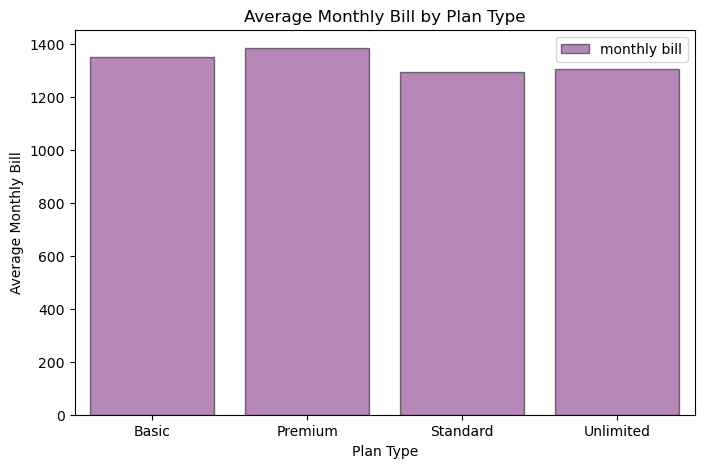

In [46]:
# chart 1 
# bar chart-"Used to compare values across different categories"
plt.figure(figsize=(8,5))
data = telecom.groupby("plan_type")["monthly_bill"].mean()
sns.barplot(x=data.index,y=data.values,color="purple",label="monthly bill",
            alpha=0.5, edgecolor="black")
plt.title("Average Monthly Bill by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Average Monthly Bill")
plt.legend()
plt.show()

In [32]:
#chart2
#scatterpolt-Relationship / correlation between two numerical variables
#For example, postpaid service-la customer first service-a use pannuvanga. Month mudinjathum bill varum. Customer evlo data use pannirukanga, 
#athukku monthly bill-la enna change irukku nu scatter use panni pakkalam

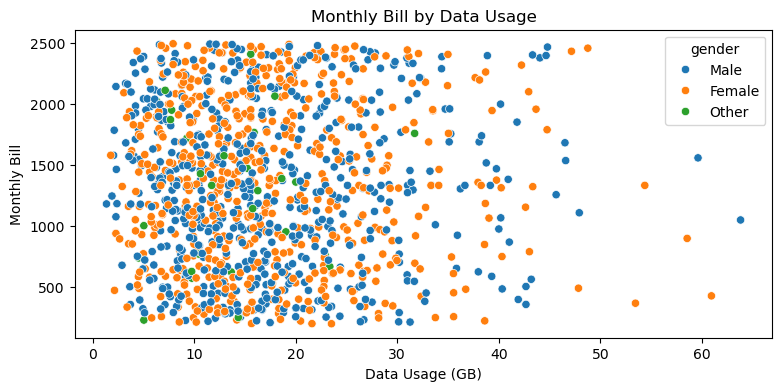

In [33]:

plt.figure(figsize=(9,4))
sns.scatterplot(x="data_usage_gb",y="monthly_bill",data=telecom,hue="gender")
plt.title("Monthly Bill by Data Usage")
plt.xlabel("Data Usage (GB)")
plt.ylabel("Monthly Bill")
plt.show()

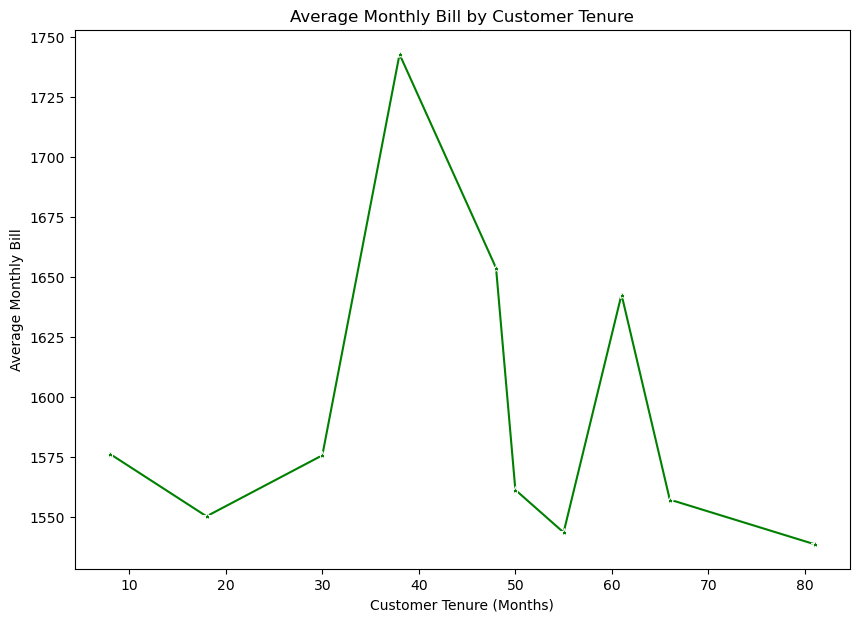

In [34]:
# chart 3
# line plot - Trend / Change

plt.figure(figsize=(10,7))
data = telecom.groupby("customer_tenure_months")["monthly_bill"].mean().nlargest(10)
sns.lineplot(x=data.index,y=data.values,marker="*",color="green")
plt.title("Average Monthly Bill by Customer Tenure")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Average Monthly Bill")
plt.show()


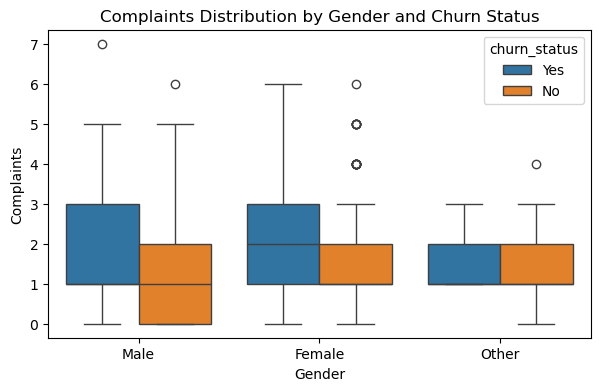

In [35]:
#chart 4
#box plot=Box Plot is used to compare the distribution, spread, median, and outliers of numerical data across categories.
plt.figure(figsize=(7,4))
sns.boxplot(data=telecom,x="gender",y="complaints",hue="churn_status")
plt.title("Complaints Distribution by Gender and Churn Status")
plt.xlabel("Gender")
plt.ylabel("Complaints")
plt.show()

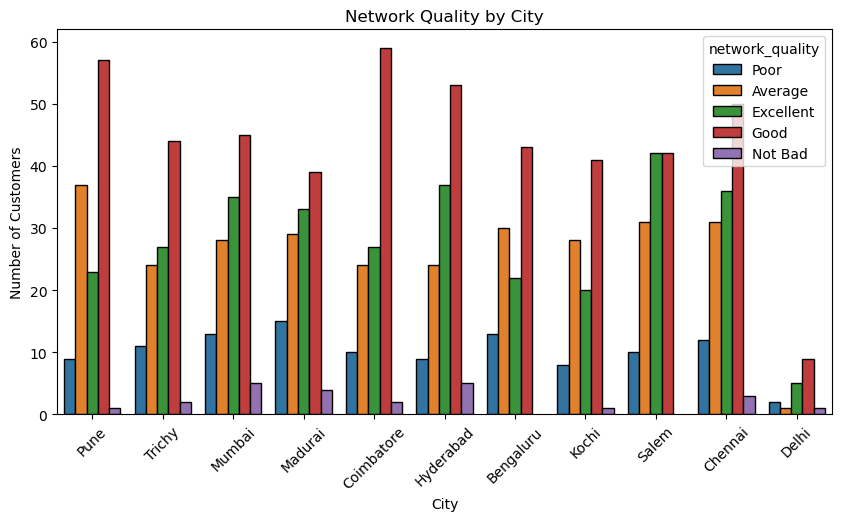

In [36]:
#chart 5
# count plot = Count Plot is used to show the number of observations in each category.
#City → Network Quality → Number of Customers.
plt.figure(figsize=(10,5))
sns.countplot(data=telecom,x="city",hue="network_quality",edgecolor="black")
plt.title("Network Quality by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

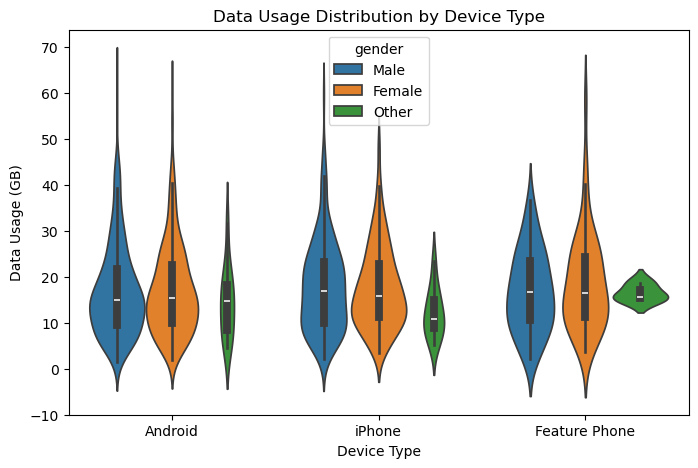

In [37]:
# chart 6
# violin plot = Shows the distribution and density of numerical data across categories.
plt.figure(figsize=(8,5))
sns.violinplot(data=telecom,x="device_type",y="data_usage_gb",hue="gender")
plt.title("Data Usage Distribution by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Data Usage (GB)")
plt.show()

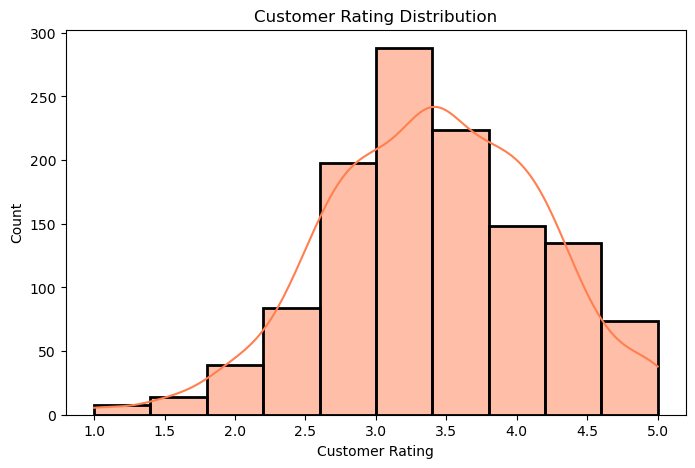

In [38]:
# chart 7
# histplot=Used to show the distribution and frequency of numerical data.
plt.figure(figsize=(8,5))
sns.histplot(data=telecom,x="customer_rating",bins=10,color="coral",edgecolor="black",linewidth=2,kde=True)
plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.show()

<Figure size 1000x800 with 0 Axes>

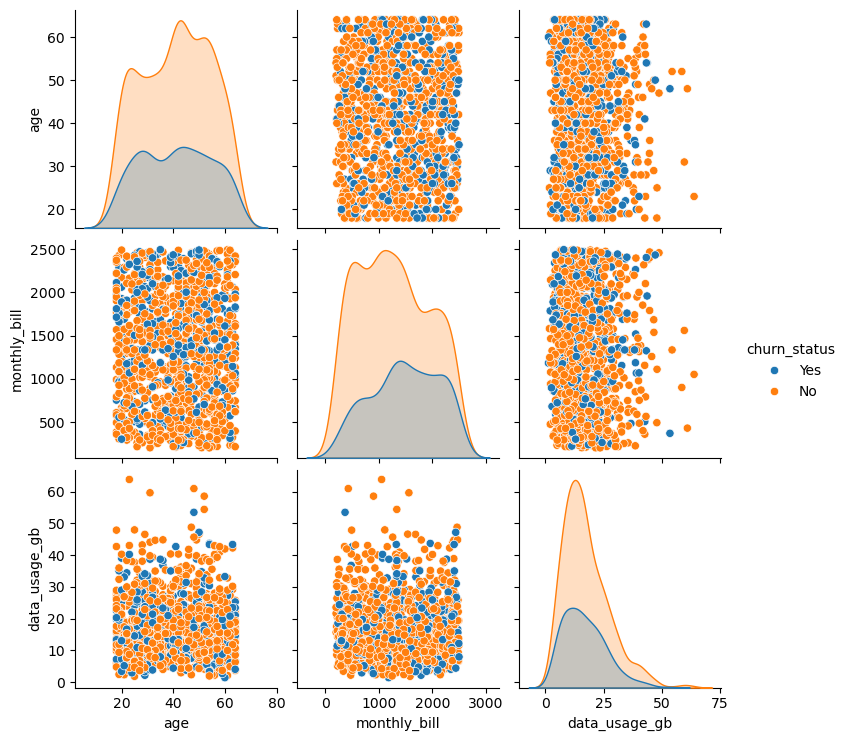

In [39]:
# chart 8
# pair plot = Shows the relationship between multiple numerical variables.
plt.figure(figsize=(10,8))
sns.pairplot(
    data=telecom,
    vars=["age", "monthly_bill", "data_usage_gb"],
    hue="churn_status"
)
plt.show()
#diagonal-self correlation-meaningless relationship

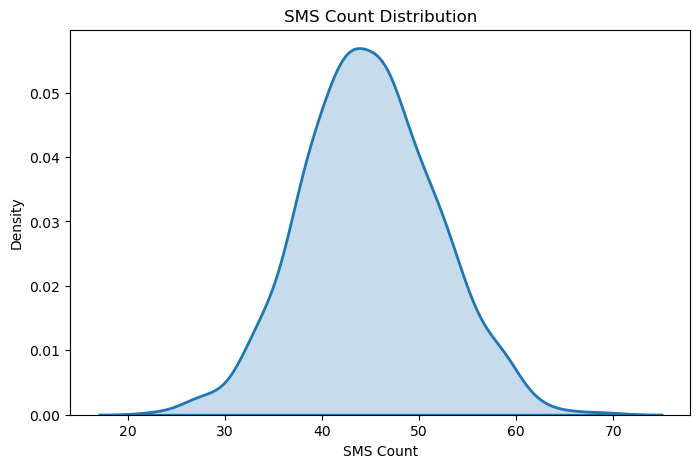

In [40]:
# chart 9
# KDE plot = Shows the distribution of numerical data using a smooth curve.
plt.figure(figsize=(8,5))
sns.kdeplot(data=telecom,x="sms_count",fill=True,linewidth=2)
plt.title("SMS Count Distribution")
plt.xlabel("SMS Count")
plt.show()

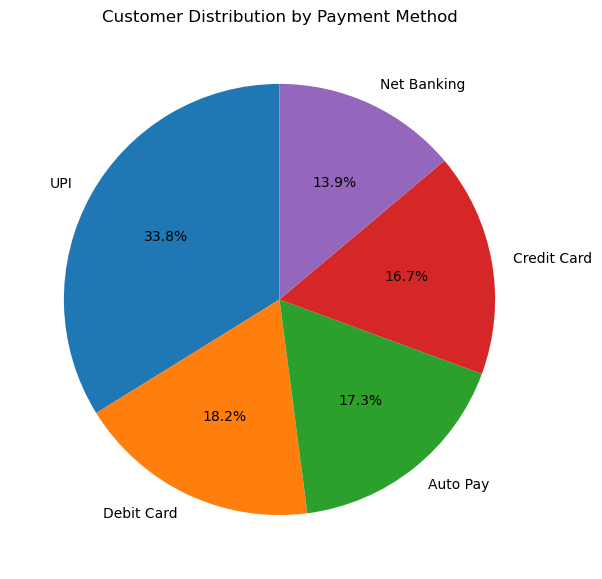

In [41]:
# chart 10
# pie chart = Shows the proportion of each category.
#payment Method → Customer Count → Percentage / Proportion
#Proportion = Share or percentage of the total.
data = telecom["payment_method"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    data.values,
    labels=data.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Distribution by Payment Method")
plt.show()

In [42]:
telecom.columns

Index(['customer_id', 'age', 'gender', 'city', 'plan_type', 'monthly_bill',
       'data_usage_gb', 'call_minutes', 'sms_count', 'complaints',
       'customer_tenure_months', 'payment_method', 'network_quality',
       'support_calls', 'device_type', 'churn_status', 'customer_rating'],
      dtype='object')

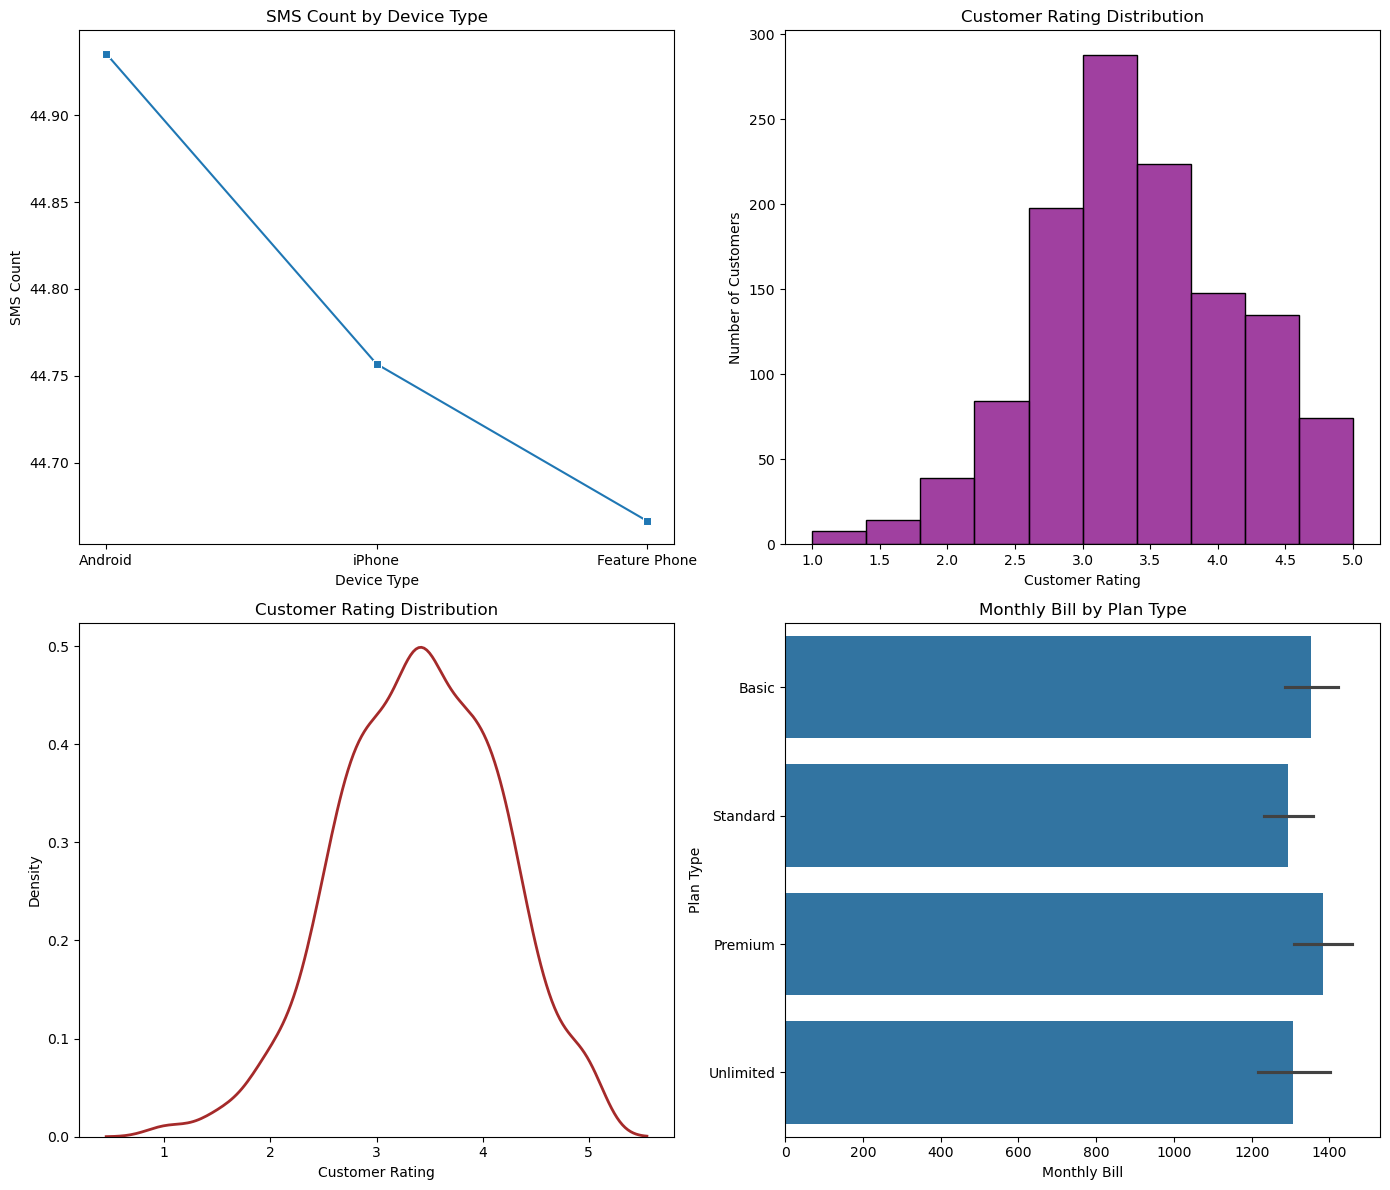

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14,12))
# Chart 1 - Line Plot
sns.lineplot(data=telecom,x="device_type",y="sms_count", marker="s",ax=axes[0,0],errorbar=None)
axes[0,0].set_title("SMS Count by Device Type")
axes[0,0].set_xlabel("Device Type")
axes[0,0].set_ylabel("SMS Count")
plt.tight_layout()

# Chart 2 - Histplot
sns.histplot(data=telecom,x="customer_rating",bins=10,color="purple",ax=axes[0,1],edgecolor="black")
axes[0,1].set_title("Customer Rating Distribution")
axes[0,1].set_xlabel("Customer Rating")
axes[0,1].set_ylabel("Number of Customers")

# Chart 3 - KDE Plot
sns.kdeplot(data=telecom,x="customer_rating",color="brown",linewidth=2,ax=axes[1,0])
axes[1,0].set_title("Customer Rating Distribution")
axes[1,0].set_xlabel("Customer Rating")
axes[1,0].set_ylabel("Density")

# Chart 4 - Horizontal Bar Plot
sns.barplot(data=telecom,x="monthly_bill",y="plan_type",orient="h",ax=axes[1,1])
axes[1,1].set_title("Monthly Bill by Plan Type")
axes[1,1].set_xlabel("Monthly Bill")
axes[1,1].set_ylabel("Plan Type")

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_20372\1002038907.py:29: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:purple'` for the same effect.

  sns.swarmplot(data=telecom, x="plan_type", y="customer_rating", color="purple", ax=axes[1,1],


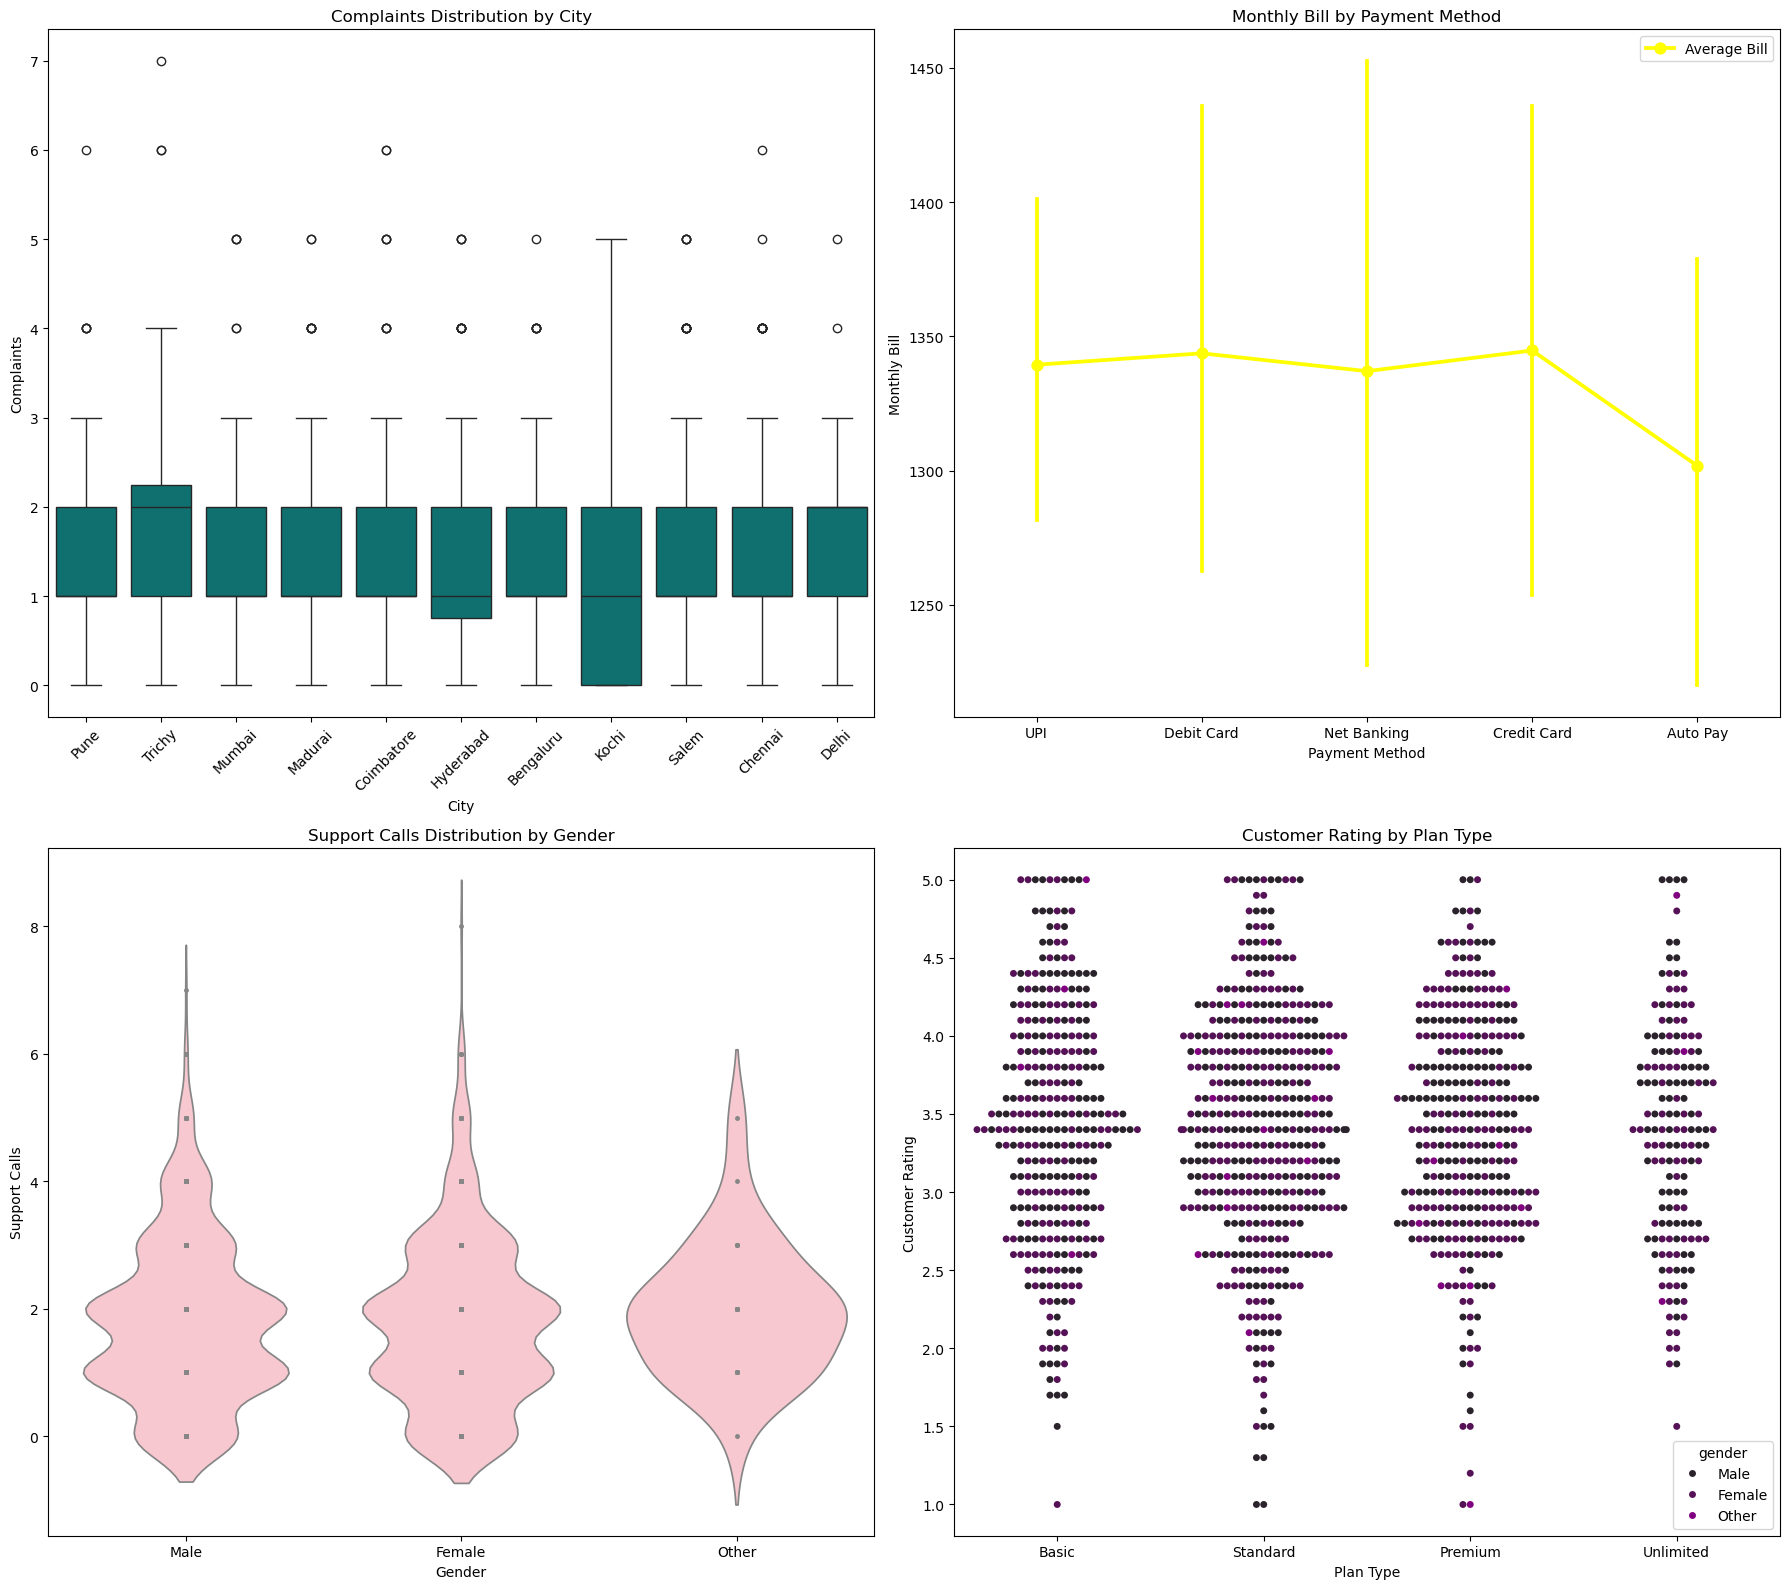

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(18,16))
# chart 1 
#box plot
sns.boxplot(data=telecom,x="city",y="complaints",color="teal",ax=axes[0,0])
axes[0,0].set_title("Complaints Distribution by City")
axes[0,0].set_xlabel("City")
axes[0,0].set_ylabel("Complaints")
axes[0,0].tick_params(axis="x",rotation=45)

# chrat 2 pointpolt-Point plot is used to compare the central value of a numerical variable across different categories
# The point shows the mean, and the line shows the range of uncertainty around the mean-"range"
sns.pointplot(data=telecom,x="payment_method",y="monthly_bill",color="yellow",ax=axes[0,1],label="Average Bill")
axes[0,1].set_title("Monthly Bill by Payment Method")
axes[0,1].set_xlabel("Payment Method")
axes[0,1].set_ylabel("Monthly Bill")
axes[0,1].legend()

#chart 3 violinplot
#inner="box" → Median & quartiles
#inner="point" → Individual data points
sns.violinplot(data=telecom,x="gender",y="support_calls",color="pink",ax=axes[1,0],inner="point")
axes[1,0].set_title("Support Calls Distribution by Gender")
axes[1,0].set_xlabel("Gender")
axes[1,0].set_ylabel("Support Calls")

#chart 4 
# swarmplot= A Swarm Plot shows individual data points across different categories without overlapping.
#Plan Type → Customer Rating → Each point-side-by-side = One customer
sns.swarmplot(data=telecom, x="plan_type", y="customer_rating", color="purple", ax=axes[1,1],
              size=5,hue="gender")
axes[1,1].set_title("Customer Rating by Plan Type")
axes[1,1].set_xlabel("Plan Type")
axes[1,1].set_ylabel("Customer Rating")

plt.tight_layout()
plt.show()


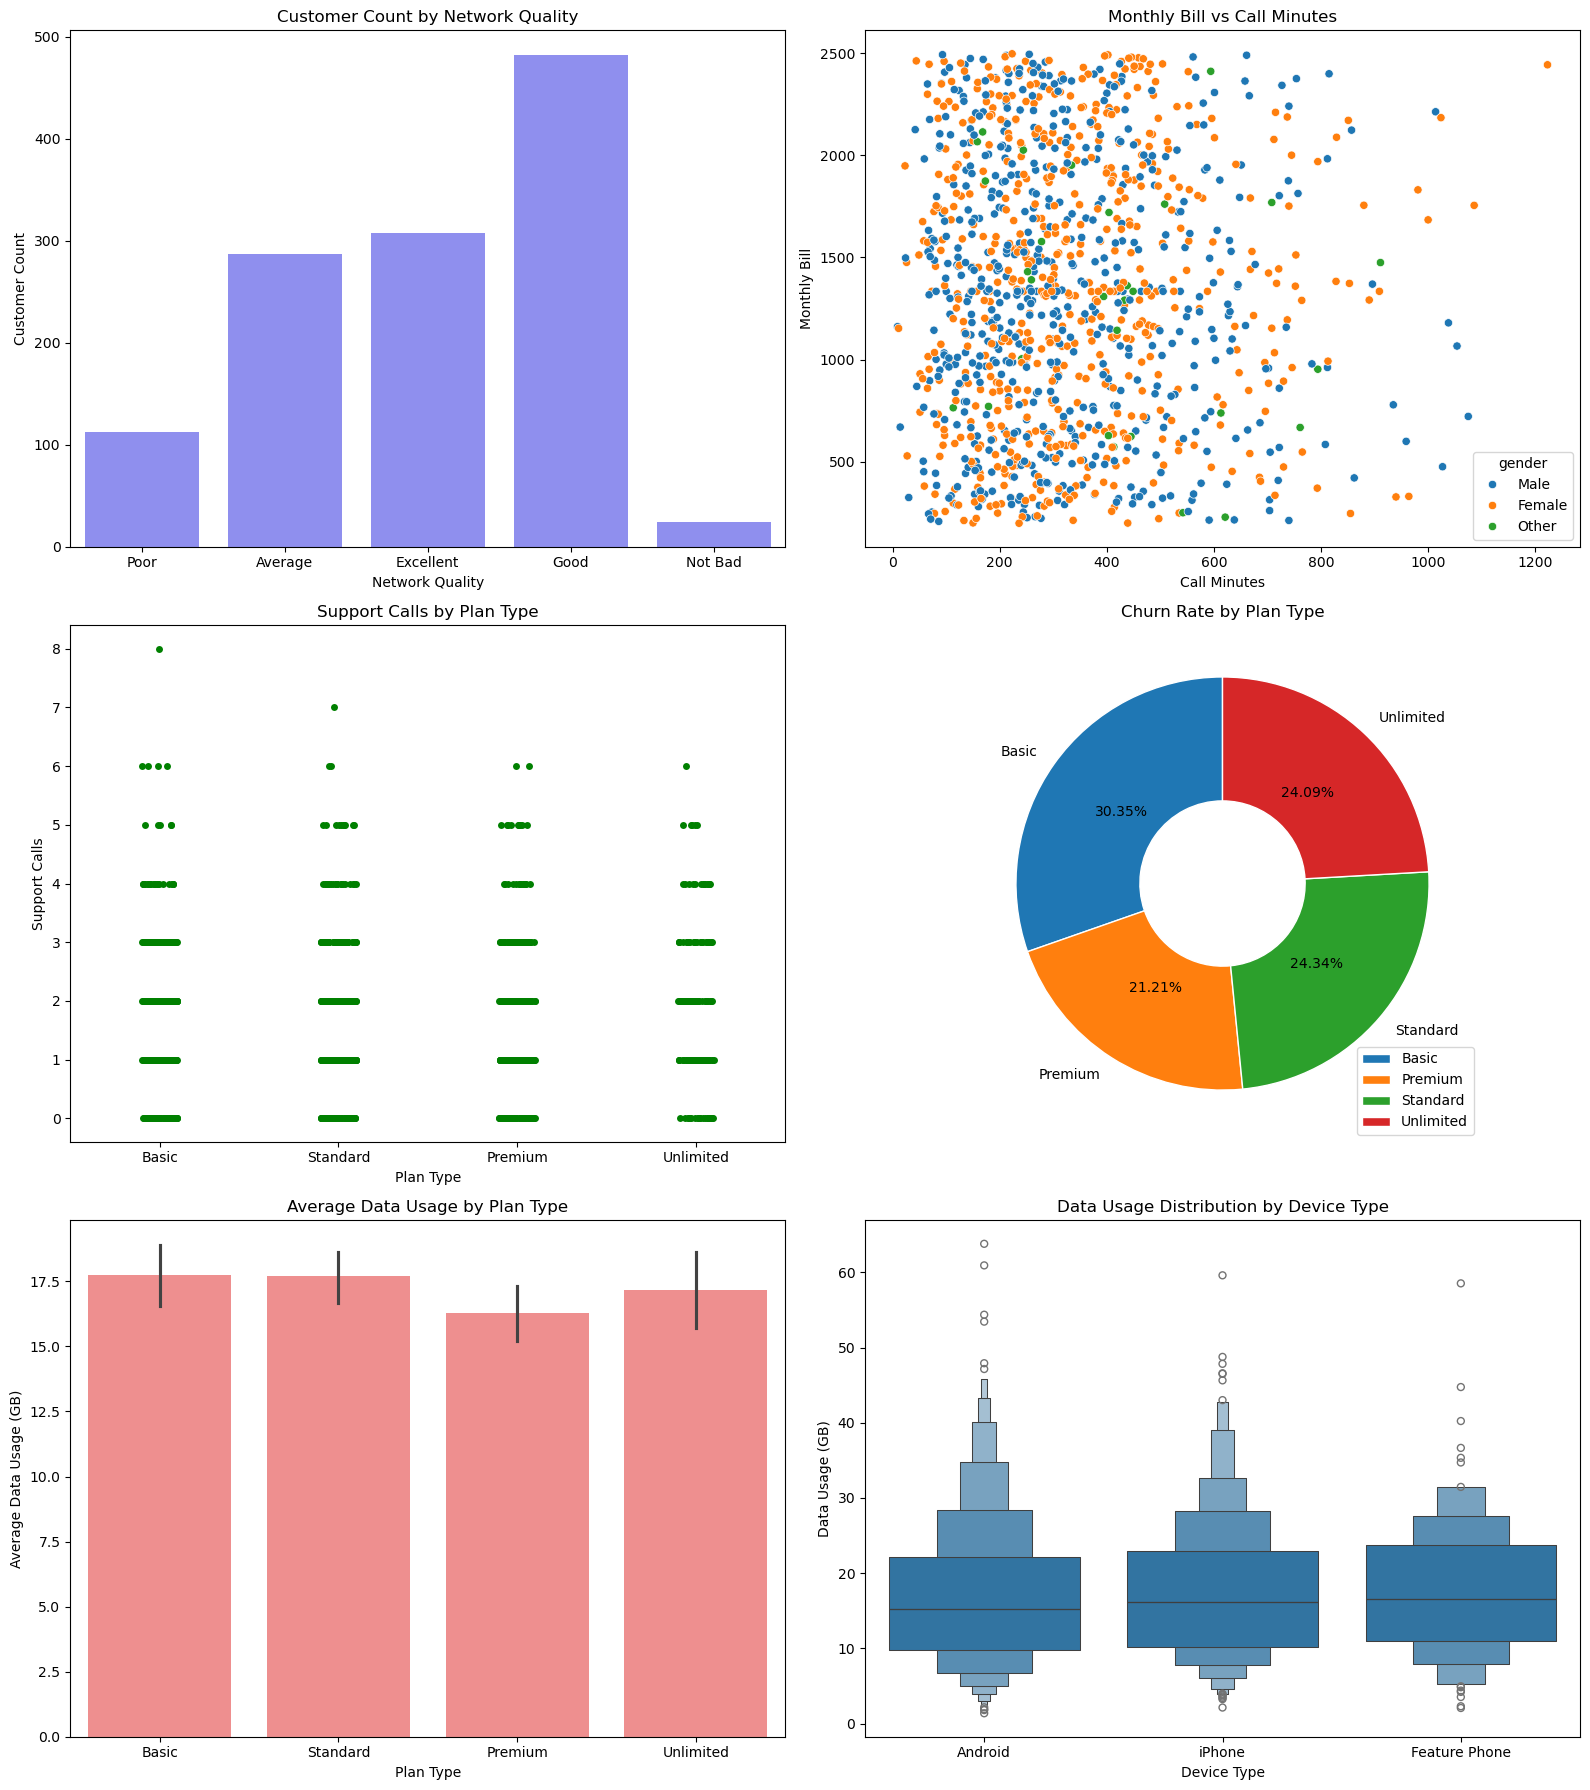

In [45]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Chart 1 - Count Plot
sns.countplot(data=telecom,x="network_quality",color="blue",ax=axes[0,0],alpha=0.5)
axes[0,0].set_title("Customer Count by Network Quality")
axes[0,0].set_xlabel("Network Quality")
axes[0,0].set_ylabel("Customer Count")

# Chart 2 - Scatter Plot
sns.scatterplot(data=telecom,x="call_minutes",y="monthly_bill",ax=axes[0,1],hue="gender")
axes[0,1].set_title("Monthly Bill vs Call Minutes")
axes[0,1].set_xlabel("Call Minutes")
axes[0,1].set_ylabel("Monthly Bill")

# Chart 3 Strip Plot-indidiual point with overlapping
sns.stripplot(data=telecom,x="plan_type",y="support_calls",color="green",
              ax=axes[1,0])
axes[1,0].set_title("Support Calls by Plan Type")
axes[1,0].set_xlabel("Plan Type")
axes[1,0].set_ylabel("Support Calls")

#chart 4 donut-Donut chart is used to show the percentage or proportion of different categories in a whole.
#basic
# Yes, No, Yes, No, Yes
#Mean = 3/5 = 0.6
churn_rate = telecom.groupby("plan_type")["churn_status"].apply(
    lambda x: (x == "Yes").mean() * 100
)
axes[1,1].pie(
    churn_rate.values,
    labels=churn_rate.index,
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"width": 0.6, "edgecolor": "white"}
)
axes[1,1].set_title("Churn Rate by Plan Type")
axes[1,1].legend(loc="lower right")

# chart 5 barpolt
sns.barplot(data=telecom,x="plan_type",y="data_usage_gb",color="red",ax=axes[2,0],alpha=0.5)
axes[2,0].set_title("Average Data Usage by Plan Type")
axes[2,0].set_xlabel("Plan Type")
axes[2,0].set_ylabel("Average Data Usage (GB)")

# Chart 6 boxen plot-Boxen plot is used to visualize and compare the distribution of numerical data across different categories
#Box plot → distribution-oda basic summary, median, quartiles, outliers.
#Boxen plot -large dataset-distribution-oda different levels/quantiles-more detailed
#whishkers
sns.boxenplot(data=telecom,x="device_type",y="data_usage_gb",ax=axes[2,1])
axes[2,1].set_title("Data Usage Distribution by Device Type")
axes[2,1].set_xlabel("Device Type")
axes[2,1].set_ylabel("Data Usage (GB)")

plt.tight_layout()
plt.show()